# AI Infrastructure Market Pulse

This notebook uses real public market-price data as a proxy for market attention around AI infrastructure. It does not claim to measure audited revenue, capex, or valuation.

No synthetic fallback is used. If market data cannot be fetched, the notebook stops.


In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from examples.hot_trends.data import (
    HotTrendDataError,
    append_real_snapshot,
    build_arxiv_monthly_counts,
    fetch_coingecko_market_chart,
    fetch_defillama_stablecoin_chains,
    fetch_github_repo_metadata,
    fetch_github_stargazers,
    fetch_huggingface_models,
    fetch_wikipedia_pageviews,
    source_audit_table,
)
from examples.hot_trends.decomposition import (
    component_summary,
    decompose_table,
    editorial_priority,
    residual_event_table,
)
from examples.hot_trends.scoring import article_language_guardrails

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
plt.rcParams.update({"axes.grid": True})

CACHE_DIR = Path("examples/hot_trends/cache")
OUTPUT_DIR = Path("examples/hot_trends/outputs")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def save_table(df, name):
    path = OUTPUT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print(f"saved: {path.as_posix()}")


## 1. Fetch real prices through yfinance


In [2]:
try:
    import yfinance as yf
except Exception as exc:
    raise ImportError("Install yfinance to run this notebook: python -m pip install yfinance") from exc

tickers = ["NVDA", "AMD", "AVGO", "MSFT", "GOOGL", "AMZN", "META", "TSLA"]
raw = yf.download(tickers, start="2024-01-01", progress=False, auto_adjust=True)["Close"]
if raw.empty:
    raise HotTrendDataError("yfinance returned no real market data")
prices = raw.reset_index().melt(id_vars="Date", var_name="ticker", value_name="price").rename(columns={"Date": "date"})
prices = prices.dropna(subset=["price"])
prices.head(20)


,date,ticker,price
0,2024-01-02,AMD,138.580002
1,2024-01-03,AMD,135.320007
2,2024-01-04,AMD,136.009995
3,2024-01-05,AMD,138.580002
4,2024-01-08,AMD,146.179993
5,2024-01-09,AMD,149.259995
6,2024-01-10,AMD,148.539993
7,2024-01-11,AMD,148.020004
8,2024-01-12,AMD,146.559998
9,2024-01-16,AMD,158.740005


## 2. Audit real price table


In [3]:
audit = source_audit_table(prices, value_col="price", entity_col="ticker", time_col="date")
audit


,series,first_timestamp,last_timestamp,observations,missing_ratio,min_value,max_value
0,AMD,2024-01-02 00:00:00,2026-05-22 00:00:00,600,0.0,78.209999,468.660004
1,AMZN,2024-01-02 00:00:00,2026-05-22 00:00:00,600,0.0,144.570007,274.989990
2,AVGO,2024-01-02 00:00:00,2026-05-22 00:00:00,600,0.0,102.365150,439.790009
3,GOOGL,2024-01-02 00:00:00,2026-05-22 00:00:00,600,0.0,130.322876,402.619995
4,META,2024-01-02 00:00:00,2026-05-22 00:00:00,600,0.0,341.787811,788.148987
5,MSFT,2024-01-02 00:00:00,2026-05-22 00:00:00,600,0.0,351.105804,538.658569
6,NVDA,2024-01-02 00:00:00,2026-05-22 00:00:00,600,0.0,47.539940,235.740005
7,TSLA,2024-01-02 00:00:00,2026-05-22 00:00:00,600,0.0,142.050003,489.880005


## 3. Decompose normalized log prices


In [4]:
components = decompose_table(prices, entity_col="ticker", time_col="date", value_col="price", method="MA_BASELINE", period=21, trend_window=63, transform="log")
summary = editorial_priority(component_summary(components, entity_col="ticker", time_col="date"), entity_col="ticker")
summary


,ticker,observations,first_timestamp,last_timestamp,trend_last,trend_slope_per_step,cycle_strength_proxy,residual_std,max_abs_residual_z,method,trend_slope_per_step_rank_pct,cycle_strength_proxy_rank_pct,max_abs_residual_z_rank_pct,editorial_priority_score
2,AVGO,600,2024-01-02 00:00:00,2026-05-22 00:00:00,3.055930,0.002033,-0.515508,0.492217,31.525257,MA_BASELINE,1.000,1.000,0.500,0.77500
3,GOOGL,600,2024-01-02 00:00:00,2026-05-22 00:00:00,2.996389,0.001351,-1.894456,0.500745,38.958102,MA_BASELINE,0.625,0.500,1.000,0.76875
6,NVDA,600,2024-01-02 00:00:00,2026-05-22 00:00:00,2.710921,0.001477,-0.730965,0.425031,30.495657,MA_BASELINE,0.750,0.875,0.375,0.60625
7,TSLA,600,2024-01-02 00:00:00,2026-05-22 00:00:00,3.037998,0.001532,-1.560162,0.528252,30.491361,MA_BASELINE,0.875,0.750,0.250,0.56875
4,META,600,2024-01-02 00:00:00,2026-05-22 00:00:00,3.277545,0.000695,-8.994832,0.545158,34.032693,MA_BASELINE,0.500,0.375,0.625,0.53125
1,AMZN,600,2024-01-02 00:00:00,2026-05-22 00:00:00,2.824356,0.000536,-12.698540,0.480000,38.387741,MA_BASELINE,0.250,0.250,0.750,0.47500
5,MSFT,600,2024-01-02 00:00:00,2026-05-22 00:00:00,3.058485,0.000199,-28.798835,0.536869,38.792557,MA_BASELINE,0.125,0.125,0.875,0.46250
0,AMD,600,2024-01-02 00:00:00,2026-05-22 00:00:00,2.973972,0.000667,-1.836695,0.521761,29.779490,MA_BASELINE,0.375,0.625,0.125,0.31250


## Visualization: AI infrastructure price trend index

Observed and trend components are exponentiated into comparable index levels for the leading tickers.

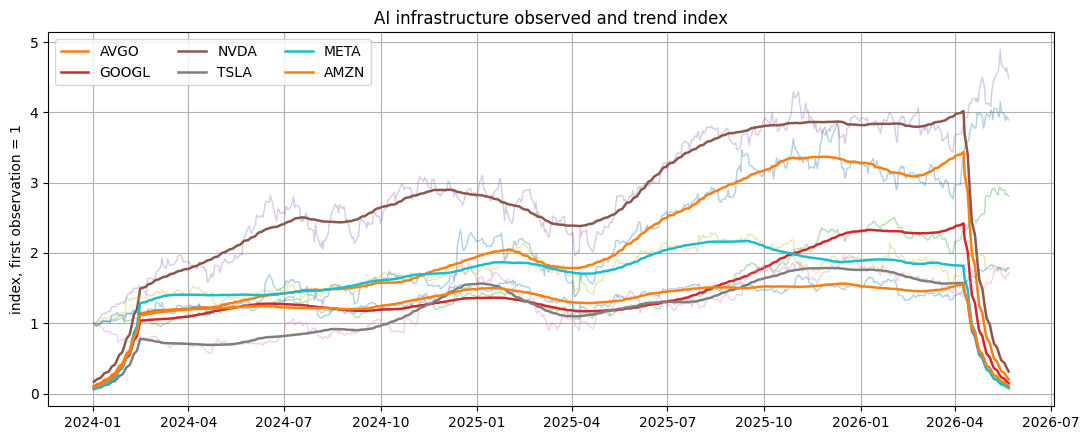

In [5]:
top_tickers = summary["ticker"].head(6).tolist()
fig, ax = plt.subplots(figsize=(11, 4.5))
for ticker in top_tickers:
    panel = components.loc[components["ticker"].eq(ticker)].sort_values("date").copy()
    panel["date"] = pd.to_datetime(panel["date"])
    base = float(panel["observed"].iloc[0])
    observed_index = np.exp(panel["observed"] - base)
    trend_index = np.exp(panel["trend"] - base)
    ax.plot(panel["date"], observed_index, linewidth=1.0, alpha=0.35)
    ax.plot(panel["date"], trend_index, linewidth=1.8, label=ticker)
ax.set_title("AI infrastructure observed and trend index")
ax.set_ylabel("index, first observation = 1")
ax.legend(ncol=3, loc="best")
plt.tight_layout()
plt.show()


## 4. Cross-sectional AI infrastructure table


In [6]:
latest = prices.sort_values("date").groupby("ticker").tail(1).rename(columns={"price": "latest_price"})
first = prices.sort_values("date").groupby("ticker").head(1).rename(columns={"price": "first_price"})[["ticker", "first_price"]]
returns = latest.merge(first, on="ticker", how="left")
returns["total_return_proxy"] = returns["latest_price"] / returns["first_price"] - 1.0
returns.sort_values("total_return_proxy", ascending=False)


,date,ticker,latest_price,first_price,total_return_proxy
6,2026-05-22,NVDA,215.770004,48.138569,3.482269
3,2026-05-22,AVGO,412.281189,105.914238,2.892595
5,2026-05-22,AMD,468.660004,138.580002,2.381873
0,2026-05-22,GOOGL,384.470001,137.037399,1.805584
4,2026-05-22,AMZN,267.480011,149.929993,0.784033
2,2026-05-22,META,610.179993,343.593628,0.775877
7,2026-05-22,TSLA,428.209991,248.419998,0.723734
1,2026-05-22,MSFT,418.934998,363.801453,0.151548


## Visualization: return versus trend slope

The scatter compares simple market return with the De-Time trend slope and residual shock size.

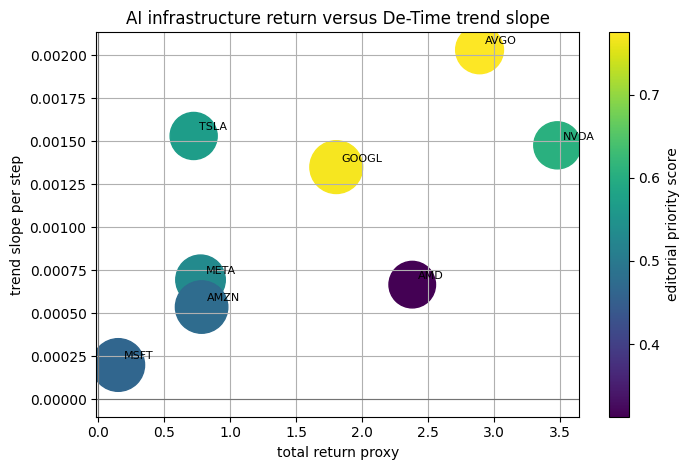

In [7]:
scatter_data = returns.merge(summary[["ticker", "trend_slope_per_step", "max_abs_residual_z", "editorial_priority_score"]], on="ticker", how="left")
fig, ax = plt.subplots(figsize=(7.2, 4.8))
sc = ax.scatter(
    scatter_data["total_return_proxy"],
    scatter_data["trend_slope_per_step"],
    s=80 + scatter_data["max_abs_residual_z"].fillna(0) * 35,
    c=scatter_data["editorial_priority_score"],
    cmap="viridis",
)
for _, row in scatter_data.iterrows():
    ax.annotate(str(row["ticker"]), (row["total_return_proxy"], row["trend_slope_per_step"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.axvline(0, color="0.45", linewidth=0.8)
ax.axhline(0, color="0.45", linewidth=0.8)
ax.set_xlabel("total return proxy")
ax.set_ylabel("trend slope per step")
ax.set_title("AI infrastructure return versus De-Time trend slope")
fig.colorbar(sc, ax=ax, label="editorial priority score")
plt.tight_layout()
plt.show()


## 5. Residual events


In [8]:
events = residual_event_table(components, entity_col="ticker", time_col="date", top_n=25)
events


,date,ticker,observed,trend,season,residual,residual_z,abs_residual_z,method
0,2026-05-22,GOOGL,5.951866,2.996389,0.040764,2.914713,38.958102,38.958102,MA_BASELINE
1,2026-05-22,MSFT,6.037716,3.058485,0.041976,2.937254,38.792557,38.792557,MA_BASELINE
2,2026-05-22,AMZN,5.589045,2.824356,0.033642,2.731047,38.387741,38.387741,MA_BASELINE
3,2026-05-21,GOOGL,5.960129,3.087816,0.038749,2.833564,37.869965,37.869965,MA_BASELINE
4,2026-05-21,MSFT,6.038086,3.152501,0.042170,2.843415,37.552506,37.552506,MA_BASELINE
5,2024-01-02,MSFT,5.896608,3.028852,0.032678,2.835078,37.442343,37.442343,MA_BASELINE
6,2026-05-21,AMZN,5.592702,2.910059,0.032498,2.650145,37.245690,37.245690,MA_BASELINE
7,2026-05-20,GOOGL,5.963348,3.178638,0.035737,2.748972,36.735665,36.735665,MA_BASELINE
8,2026-05-20,MSFT,6.040612,3.246430,0.042988,2.751195,36.333850,36.333850,MA_BASELINE
9,2024-01-03,MSFT,5.895880,3.123838,0.029370,2.742672,36.221224,36.221224,MA_BASELINE


## Visualization: AI infrastructure residual heatmap

The residual heatmap shows when market-price deviations cluster across tickers.

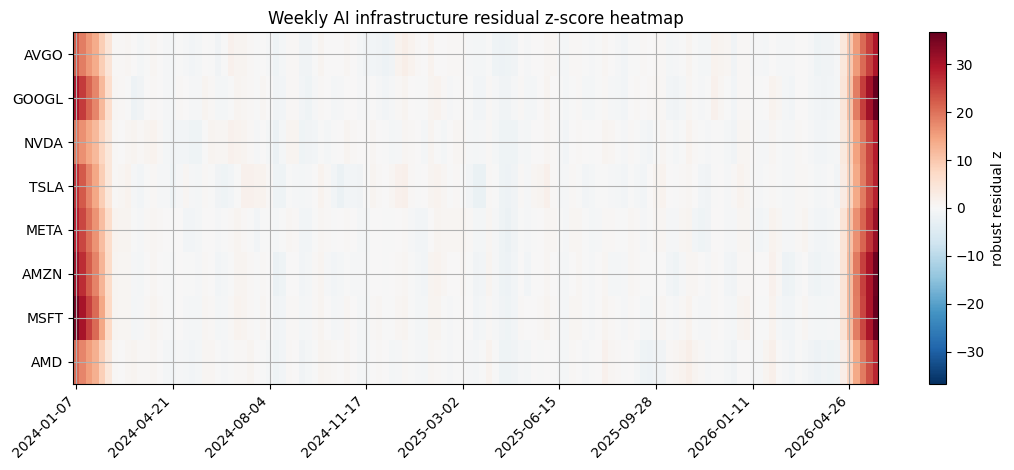

In [9]:
residual_grid = components.copy()
residual_grid["residual_z"] = residual_grid.groupby("ticker")["residual"].transform(lambda s: (s - s.median()) / (1.4826 * (s - s.median()).abs().median() + 1e-12))
heat = residual_grid.pivot_table(index="ticker", columns="date", values="residual_z", aggfunc="mean").reindex(summary["ticker"].tolist()).dropna(how="all")
heat = heat.T
heat.index = pd.to_datetime(heat.index)
heat = heat.resample("W").mean().T
values = heat.to_numpy(dtype=float)
absmax = float(np.nanmax(np.abs(values))) if np.isfinite(values).any() else 1.0
fig, ax = plt.subplots(figsize=(11, 4.8))
im = ax.imshow(values, aspect="auto", cmap="RdBu_r", vmin=-absmax, vmax=absmax)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
tick_step = max(1, len(heat.columns) // 8)
xticks = list(range(0, len(heat.columns), tick_step))
ax.set_xticks(xticks)
ax.set_xticklabels([heat.columns[i].strftime("%Y-%m-%d") for i in xticks], rotation=45, ha="right")
ax.set_title("Weekly AI infrastructure residual z-score heatmap")
fig.colorbar(im, ax=ax, label="robust residual z")
plt.tight_layout()
plt.show()


## 6. Guardrails


In [10]:
guardrails = article_language_guardrails()
guardrails


,unsafe,safer
0,This trend predicts the next price move.,This trend summarizes the observed public seri...
1,This model is better because it has more downl...,Downloads are a public adoption proxy and shou...
2,This repo is winning because stars are rising.,"Star velocity measures developer attention, no..."
3,This pageview spike proves importance.,Pageviews measure public attention during the ...
4,This residual is a buy signal.,This residual marks an event-like deviation fr...


In [11]:
save_table(audit, "07_ai_infra_market_audit")
save_table(summary, "07_ai_infra_component_summary")
save_table(returns, "07_ai_infra_return_proxy")
save_table(events, "07_ai_infra_residual_events")
save_table(guardrails, "07_ai_infra_guardrails")


saved: examples/hot_trends/outputs/07_ai_infra_market_audit.csv
saved: examples/hot_trends/outputs/07_ai_infra_component_summary.csv
saved: examples/hot_trends/outputs/07_ai_infra_return_proxy.csv
saved: examples/hot_trends/outputs/07_ai_infra_residual_events.csv
saved: examples/hot_trends/outputs/07_ai_infra_guardrails.csv
